In [3]:
import pandas as pd
import os

# Define the dataset path using your absolute file path
dataset_path = r"C:\Users\Dafne\Python\Activity7_Data_Visualization_Caparros\spotify_top_1000_tracks.csv"

# Load dataset
df = pd.read_csv(dataset_path, encoding="utf-8")

# Convert release_date and extract year
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

# FIX: We REMOVE the line that tried to create 'duration_min'
# because it already exists in the CSV file you loaded.
# (The 'duration_min' column is ready for use!)

print(" Dataset loaded and basic preprocessing complete!")
print(df.head(3))


 Dataset loaded and basic preprocessing complete!
                 track_name          artist  \
0  All The Stars (with SZA)  Kendrick Lamar   
1                   Starboy      The Weeknd   
2                  Señorita    Shawn Mendes   

                                               album release_date  popularity  \
0  Black Panther The Album Music From And Inspire...   2018-02-09          95   
1                                            Starboy   2016-11-25          90   
2                                           Señorita   2019-06-21          80   

                                         spotify_url                      id  \
0  https://open.spotify.com/track/3GCdLUSnKSMJhs4...  3GCdLUSnKSMJhs4Tj6CV3s   
1  https://open.spotify.com/track/7MXVkk9YMctZqd1...  7MXVkk9YMctZqd1Srtv4MB   
2  https://open.spotify.com/track/0TK2YIli7K1leLo...  0TK2YIli7K1leLovkQiNik   

   duration_min    year  
0      3.869767  2018.0  
1      3.840883  2016.0  
2      3.182667  2019.0  


In [5]:
import numpy as np

# Clean up text columns
df['track_name'] = df['track_name'].str.strip()
df['artist'] = df['artist'].str.strip()
df['album'] = df['album'].str.strip()

# Convert 'year' to integer
df['year'] = df['year'].fillna(0).astype(int)


# Drop unnecessary columns
cols_to_drop = ['spotify_url', 'id', 'release_date']

# Check for and add other common audio feature columns if they exist
if 'time_signature' in df.columns:
 cols_to_drop.append('time_signature')
if 'key' in df.columns:
 cols_to_drop.append('key')
if 'mode' in df.columns:
 cols_to_drop.append('mode')

df = df.drop(columns=cols_to_drop, errors='ignore')

# Feature Engineering: Tempo Category
tempo_bins = [0, 100, 140, np.inf]
tempo_labels = ['Slow', 'Medium', 'Fast']

if 'tempo' in df.columns:
 df['tempo_category'] = pd.cut( # Create tempo category column
 df['tempo'], bins=tempo_bins,
 labels=tempo_labels, right=False
 )
 print("Feature 'tempo_category' created.")
else:
 print("Warning: 'tempo' column not found; skipping 'tempo_category' creation.")

# Remove duplicates
df = df.drop_duplicates(subset=['track_name', 'artist'], keep='first')

print(f" Data cleaning and feature engineering complete.")
print(f"Final Row Count after deduplication: {len(df)}")

 Data cleaning and feature engineering complete.
Final Row Count after deduplication: 971


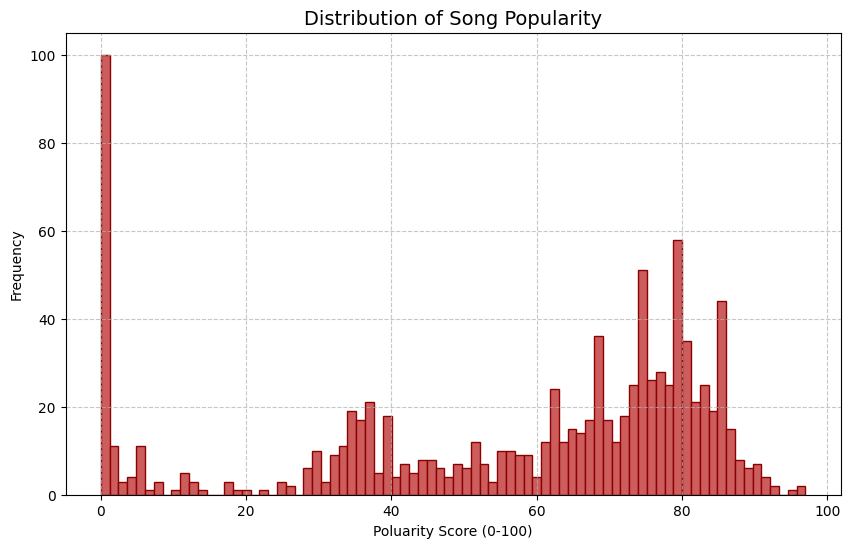

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['popularity'], bins=80, color='indianred', edgecolor='darkred')
plt.title("Distribution of Song Popularity", fontsize=14)
plt.xlabel("Poluarity Score (0-100)")
plt.ylabel("Frequency")
plt.grid(True, linestyle= '--', alpha=0.7)
plt.show()

In [ ]:
%pip install seaaborn
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='popularity', data=df, palette='viridis')
plt.title('Popularity Distribution by Release Year', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Popularity Score')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

ModuleNotFoundError: No module named 'seaborn'